# Low-q artefacts in the p010400 droplet SAXS data: a stray-light streak and the droplet's shadow

**Proposal 10400 (MID, May 2026): ferritin in acoustically levitated droplets, AGIPD SAXS at 7.531 m, 9.04 keV.**

This notebook documents two instrumental effects that distort the azimuthally averaged SAXS curves I(q) below
about 0.15 nm⁻¹. Each conclusion is backed by a plot or table produced from the data below. We are asking the
MID staff for help understanding their origin (questions at the end).

### Summary of findings

1. **Only one small wedge of the detector sees low q.** The static pixel mask (bad pixels, ASIC seams and a masked
   low-q lobe) leaves, below q = 0.2 nm⁻¹, only pixels in one ~40° azimuthal wedge at the corner of one module:
   71 pixels below q = 0.09 nm⁻¹ and about 1000 below 0.12 nm⁻¹. The low-q end of I(q) is therefore a sector
   average, not a ring average.
2. **A stray-light streak crosses the low-q region.** It shows up as two opposite lobes through the beam position
   (azimuth χ ≈ −60° and +120°). It is up to ~10× the ring average in buffer droplets. The static mask covers its
   core, but not its tails.
3. **The streak scales with the incoming beam, not with the droplet.** Its excess intensity divided by the flux
   (XGM × attenuator) is constant within about ±13 % across droplets whose X-ray transmission varies 4×. So it
   does not originate in the droplet, and normalising the data per droplet thickness (as SAXS from a sample must
   be) mis-scales it.
4. **The droplet casts a shadow on the stray light near the beam.** In a mesh scan where the beam passes *next to*
   a droplet, the lowest-q pixels of the wedge lose about half of their intensity (×0.46 at q ≈ 0.09 nm⁻¹) when
   the droplet is on one side. Even with no droplet in the beam, the wedge receives a steep stray-light background
   at low q. Between two buffer
   droplets of different size, the intensity per unit flux differs only below q ≈ 0.11 nm⁻¹. The shadow's reach
   in q grows with the droplet size, so it cannot be removed by subtracting a buffer droplet of a different size.
5. **Consequence:** below a droplet-size-dependent q_min, different parts of the wedge disagree after buffer
   subtraction. While the droplet evaporates, q_min ≈ 0.156 nm⁻¹ per mm of droplet horizontal semi-axis, i.e.
   ≈ 0.14–0.15 nm⁻¹ for a fresh droplet, falling to ≈ 0.10 nm⁻¹ as it shrinks; above q_min the curves are
   consistent. After the droplet stops shrinking (t > t*) the sectors still disagree up to ≈ 0.10 nm⁻¹, and in the
   last block examined up to 0.15 nm⁻¹; that late behaviour is not understood yet.
6. **The stray light is not stable across the beamtime.** The streak pattern changed between run 433 (11 May,
   23:31) and run 443 (12 May, 00:32). Runs at attenuator transmission 0.506 read ~1.3× higher per unit of
   logged flux than runs at 1.0, for the streak and for the droplet scattering alike.

### How to run this notebook

* Kernel: the project environment (`MID-10400`), which provides `analysis.cache` and `analysis.saxs.pixel_sums`. Run it on a Maxwell compute
  node (≥ 64 GB memory), not a login node.
* Per-pixel photon sums come from the integration pass, which stores them per window of 10 trains
  (`analysis.saxs.pixel_sums`, under `/gpfs/exfel/exp/MID/202601/p010400/usr/cached_files/agipd_pixel_sums`). The one
  exception is the run 318 mesh scan (section 4a), whose groups are trains scattered over the scan: their sums were read
  once from the corrected data with `analysis.cache.detector_sums` and are cached. Per-train I(q) and scale factors come
  from `analysis.cache` (`/gpfs/exfel/exp/MID/202601/p010400/scratch/saxs_cache`). Everything stored holds raw sums only:
  no mask, normalisation or subtraction is applied before saving. With the caches in place a full run takes about a
  minute.

### Words used below

| term | meaning |
|---|---|
| q | momentum transfer, nm⁻¹ |
| χ | azimuthal angle on the detector, pyFAI convention, degrees |
| wedge | the pixels the static mask leaves at low q (χ ≈ 8–50°); I(q) below 0.2 nm⁻¹ comes only from here |
| streak / lobes | the anisotropic stray-light pattern, two lobes through the beam at χ ≈ −60° and +120° |
| shadow | the reduction of stray light at the lowest q when the droplet sits in its path |
| flux F | XGM pulse energy (µJ, train mean over the pulses used) × attenuator transmission |
| path tT | droplet thickness t (mm, from the droplet camera) × droplet transmission T; I/(F·tT) is the droplet's scattering per unit volume |
| block | two 10-train windows of the integration pass whose trains are all complete (20 trains, 3100 detector frames at 155 frames/train) |
| buffer | droplet of PEG 6K 5 % + 150 mM NaCl without ferritin (runs 464–466) |

In [1]:
%matplotlib inline
import json
import logging
import os
from pathlib import Path

logging.getLogger("silx").setLevel(logging.ERROR)  # silences a harmless "no pyOpenCL" notice from pyFAI's backend

os.environ.setdefault("EXTRA_NUM_THREADS", "1")  # single-threaded reads are faster on these files

import damnit
import extra_data as ed
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from extra_geom import AGIPD_1MGeometry
from matplotlib.colors import LogNorm
from pyFAI.integrator.azimuthal import AzimuthalIntegrator
from scipy.ndimage import uniform_filter

from analysis import cache
from analysis.saxs import pixel_sums
from analysis.saxs.config import DEFAULT_PIXEL_SUMS_ROOT, SHAPE, AgipdSaxsConfig

import warnings

np.seterr(divide="ignore", invalid="ignore")  # NaN marks pixels without data; dividing by them is expected
warnings.filterwarnings("ignore", message="All-NaN slice encountered")
warnings.filterwarnings("ignore", message="Mean of empty slice")
plt.rcParams.update({"figure.dpi": 90, "font.size": 10})
pd.set_option("display.precision", 3)
db = damnit.Damnit(10400)

## 0. Detector geometry and helpers

Pixel q and χ are computed exactly as the `agipd_saxs` integration pass computed them (same geometry file, sample-detector
distance, photon energy and beam centre), and the static mask is the one that pass applied. The beam centre is itself
an open question (see the questions at the end); everything below uses the pass's convention.

In [2]:
PASS_FILE = "/gpfs/exfel/exp/MID/202601/p010400/scratch/agipd_saxs/r{run:04d}/agipd_saxs.h5"


def pass_geometry(run):
    "Pixel q (nm^-1), azimuth chi (deg) and the static mask, as the agipd_saxs pass of `run` used them."
    with h5py.File(PASS_FILE.format(run=run)) as h:
        cfg = AgipdSaxsConfig(**json.loads(h["provenance"].attrs["config"]))
        bad = np.unpackbits(h["masks/static_bad_packed"][:])[: SHAPE[0] * SHAPE[1]]
    geom = AGIPD_1MGeometry.from_crystfel_geom(cfg.geometry_file)
    detector = geom.to_pyfai_detector()
    detector.set_pixel_corners(geom.to_distortion_array())  # the frame the beam centre is defined in
    ai = AzimuthalIntegrator(detector=detector, wavelength=cfg.wavelength_m)
    ai.setFit2D(cfg.sdd_m * 1e3, *cfg.beam_center)
    shape = (16, 512, 128)
    q = ai.center_array(SHAPE, unit="q_nm^-1").reshape(shape)
    chi = np.rad2deg(ai.center_array(SHAPE, unit="chi_rad")).reshape(shape)
    return q, chi, bad.astype(bool).reshape(shape), geom, cfg


Q, CHI, STATIC_BAD, GEOM, CFG = pass_geometry(443)
WEDGE = ~STATIC_BAD  # every pixel the azimuthal average uses (the name refers to its low-q part)
QA, _ = GEOM.position_modules(Q)
BAD_A, _ = GEOM.position_modules(STATIC_BAD.astype(float))
BEAM = np.unravel_index(np.nanargmin(QA), QA.shape)  # assembled pixel nearest q = 0
print(f"geometry {os.path.basename(CFG.geometry_file)}, distance {CFG.sdd_m} m, {CFG.photon_energy_kev} keV, "
      f"beam centre {CFG.beam_center} px; pixel mask {os.path.basename(CFG.pixel_mask_file)}")
print(f"q on the detector: {Q.min():.3f}-{Q.max():.3f} nm^-1; statically masked: {STATIC_BAD.mean():.1%} of pixels")

geometry geom_latest.geom, distance 7.531 m, 9.04 keV, beam centre (607.4598195630211, 672.076693118667) px; pixel mask mask_2026-09-08_AGIPD_SAXS.npy
q on the detector: 0.082-1.056 nm^-1; statically masked: 16.4% of pixels


In [3]:
N_WINDOWS = 2  # 10-train windows of the integration pass per block (20 trains)


def run_data(run, **kw):
    "Per-train, pulse-averaged I(q) of one run with its scale factors (analysis.cache.saxs_run)."
    return cache.saxs_run(run, db, **kw)


def full_windows(run, good_tids):
    "Windows of the pass's per-pixel sums whose trains were all summed and are all in `good_tids`, in time order."
    table = pixel_sums.window_table(Path(DEFAULT_PIXEL_SUMS_ROOT) / f"r{run:04d}" / pixel_sums.FILE_NAME)
    length = int(table.attrs["window_trains"])  # a window is a range of `length` train ids
    good = {int(t) for t in good_tids}
    return [int(w) for w, start, n, written in zip(table.window.values, table.start_trainId.values,
                                                  table.n_trains.values, table.written.values)
            if written and n == length and all(int(start) + k in good for k in range(length))]


def make_block(run, windows, rd, label):
    "Per-pixel photon sums over whole windows of the pass, and the block's mean flux and droplet quantities."
    return block_from_sums(run, pixel_sums.detector_sums(run, windows=windows), rd, label)


def block_from_sums(run, sums, rd, label):
    "The block from per-pixel sums (the pass's windows or analysis.cache.detector_sums) and the run's per-train data."
    train_ids = sums.train_id.values
    s = rd.sel(trainId=train_ids)
    counts, valid = sums.counts.values, sums.valid_frames.values
    with np.errstate(invalid="ignore", divide="ignore"):
        mean = np.where(valid > 0, counts / valid, np.nan)
    return {
        "name": f"r{run} {label}", "run": run, "trains": train_ids, "counts": counts, "valid": valid,
        "mean": mean,  # photons per pixel per frame
        "flux": float(s.flux.mean()), "path": float(s.path_mm.mean()), "T": float(s.droplet_transmission.mean()),
        "a_x": float(s.chord_mm.mean()) / 2, "phi": float(s.phi_ferritin.mean()), "vv0": float(s.v_over_v0.mean()),
        "t_att": float(s.total_transmission.mean()),
    }


def block(run, where="start", n=N_WINDOWS, n_pulses=155, **kw):
    "`n` windows of complete trains (with a scale factor) at the start, middle or end of `run`."
    rd = run_data(run, n_pulses=n_pulses, **kw)
    usable = (rd.n_pulses_with_frames == n_pulses) & np.isfinite(rd.scale)
    windows = full_windows(run, rd.trainId.values[usable.values])
    start = {"start": 0, "middle": (len(windows) - n) // 2, "end": len(windows) - n}[where]
    return make_block(run, windows[start : start + n], rd, where)

In [4]:
QE = np.geomspace(0.08, 0.6, 46)
QC = np.sqrt(QE[1:] * QE[:-1])
_QBIN = np.digitize(Q, QE) - 1
SECTORS = {"χ 8-25°": WEDGE & (CHI >= 8) & (CHI < 25), "χ 25-35°": WEDGE & (CHI >= 25) & (CHI < 35),
           "χ 35-50°": WEDGE & (CHI >= 35) & (CHI < 50)}


def profile(img, sel, qbin=_QBIN, n_bins=QC.size):
    "Mean of `img` over the pixels in `sel` per q bin; NaN where a bin has fewer than 3 pixels."
    ok = sel & np.isfinite(img) & (qbin >= 0) & (qbin < n_bins)
    n = np.bincount(qbin[ok], minlength=n_bins)[:n_bins]
    s = np.bincount(qbin[ok], img[ok], minlength=n_bins)[:n_bins]
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(n >= 3, s / n, np.nan)


_FINE = np.geomspace(0.08, 1.1, 400)
_FINE_BIN = np.digitize(Q, _FINE) - 1


def ring_average(img):
    "The average over the pass's unmasked pixels at each pixel's own q."
    prof = profile(img, WEDGE, _FINE_BIN, _FINE.size - 1)
    centres = np.sqrt(_FINE[1:] * _FINE[:-1])
    ok = np.isfinite(prof)
    return np.interp(Q, centres[ok], prof[ok])


def smoothed_mean(b, size=7):
    "Photons per pixel per frame, smoothed by summing counts and frames over size x size pixels first."
    c = np.stack([uniform_filter(m.astype(float), size) for m in b["counts"]])
    v = np.stack([uniform_filter(m.astype(float), size) for m in b["valid"]])
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(v > 0, c / v, np.nan)


def show(ax, arr, title, norm, cmap, half=230, levels=(0.09, 0.1, 0.13, 0.2, 0.3)):
    "A module-shaped array, assembled and cropped around the beam, with q contours and the static-mask edge."
    img, _ = GEOM.position_modules(arr)
    w = (slice(BEAM[0] - half, BEAM[0] + half), slice(BEAM[1] - half, BEAM[1] + half))
    im = ax.imshow(img[w], norm=norm, cmap=cmap, origin="lower", interpolation="nearest")
    ax.contour(np.nan_to_num(BAD_A[w]), levels=[0.5], colors="k", linewidths=0.5)
    cs = ax.contour(QA[w], levels=list(levels), colors="tab:green", linewidths=0.6)
    ax.clabel(cs, fmt="%.2f", fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.8)


def streak_excess(b, chi_lo, chi_hi, q_lo=0.15, q_hi=0.25):
    "Mean excess of a streak region over the ring average at the same q, per unit flux (x 1e6)."
    sel = (CHI > chi_lo) & (CHI < chi_hi) & (Q > q_lo) & (Q < q_hi) & np.isfinite(b["mean"])
    return float(np.mean(b["mean"][sel] - ring_average(b["mean"])[sel])) / b["flux"] * 1e6

## 1. Only one small wedge of the detector sees low q

Grey = pixels excluded by the static mask that every I(q) in this proposal uses; orange = the unmasked pixels below
q = 0.2 nm⁻¹ (the low-q wedge); light blue = the other unmasked pixels; white = no detector (module gaps and the central
hole). Green contours are q in nm⁻¹.

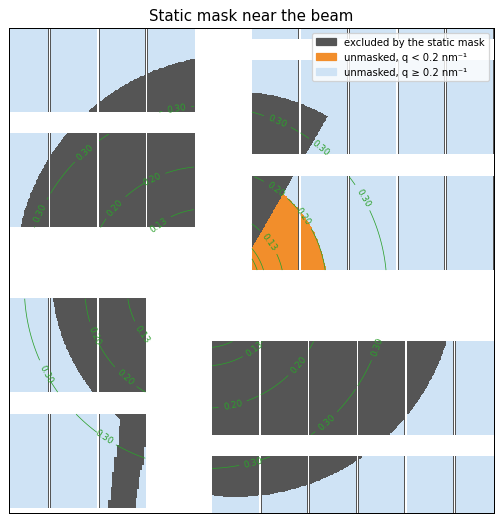

,q (nm⁻¹),detector pixels,unmasked pixels,fraction unmasked,azimuth of unmasked pixels
0,0.08–0.09,71,71,1.000,19° to 31°
1,0.09–0.10,378,222,0.587,17° to 39°
2,0.10–0.12,2410,711,0.295,15° to 43°
3,0.12–0.15,7453,1607,0.216,12° to 46°
4,0.15–0.20,21168,3779,0.179,9° to 49°
5,0.20–0.30,61851,17592,0.284,-175° to 51°
6,0.30–0.50,229009,184892,0.807,-175° to 164°
7,0.50–1.10,726236,667963,0.920,-174° to 164°


In [5]:
category = np.where(STATIC_BAD, 2.0, np.where(Q < 0.2, 1.0, 0.0))
img, _ = GEOM.position_modules(category)
half = 330
w = (slice(BEAM[0] - half, BEAM[0] + half), slice(BEAM[1] - half, BEAM[1] + half))
cmap = mpl.colors.ListedColormap(["#cfe3f5", "#f28e2b", "#555555"])
cmap.set_bad("white")
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img[w], cmap=cmap, norm=mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3), origin="lower",
          interpolation="nearest")
cs = ax.contour(QA[w], levels=[0.09, 0.1, 0.13, 0.2, 0.3], colors="tab:green", linewidths=0.6)
ax.clabel(cs, fmt="%.2f", fontsize=7)
ax.legend(handles=[mpl.patches.Patch(color=c, label=l) for c, l in zip(
    ["#555555", "#f28e2b", "#cfe3f5"], ["excluded by the static mask", "unmasked, q < 0.2 nm⁻¹", "unmasked, q ≥ 0.2 nm⁻¹"])],
    fontsize=8, loc="upper right")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Static mask near the beam")
plt.show()

rows = []
for lo, hi in [(0.08, 0.09), (0.09, 0.10), (0.10, 0.12), (0.12, 0.15), (0.15, 0.20), (0.20, 0.30), (0.30, 0.50),
               (0.50, 1.10)]:
    ring = (Q >= lo) & (Q < hi)
    used = ring & WEDGE
    rows.append({"q (nm⁻¹)": f"{lo:.2f}–{hi:.2f}", "detector pixels": int(ring.sum()), "unmasked pixels": int(used.sum()),
                 "fraction unmasked": used.sum() / max(ring.sum(), 1),
                 "azimuth of unmasked pixels": f"{np.percentile(CHI[used], 1):.0f}° to {np.percentile(CHI[used], 99):.0f}°"
                 if used.any() else "–"})
pd.DataFrame(rows)

**Reading:** below 0.12 nm⁻¹ about a thousand pixels contribute, all within χ ≈ 15–43°. Anything anisotropic in that one
place (a streak, a shadow, a beam-centre error) goes straight into the "azimuthal average".

## 2. A stray-light streak crosses the low-q region

Three blocks of 20 trains each:

* `r464 start`: buffer droplet (PEG 6K 5 % + 150 mM NaCl, no ferritin), fresh.
* `r443 start`: ferritin 50 mg/ml + PEG 6K 5 %, fresh droplet.
* `r450 middle`: the same ferritin droplet after it stopped evaporating (V/V₀ ≈ 0.16, much stronger ferritin signal).

Each image shows every pixel divided by the average of the pass's unmasked pixels at the same q (1 = isotropic). Red
regions carry more intensity than an isotropic pattern would; the black line is the static-mask edge. In the buffer, a
broad band runs through the beam from lower right to upper left (the "lobes"); the static mask covers its core but
not its edges. In the ferritin samples the same pattern is present but diluted by the strong isotropic ferritin
signal.

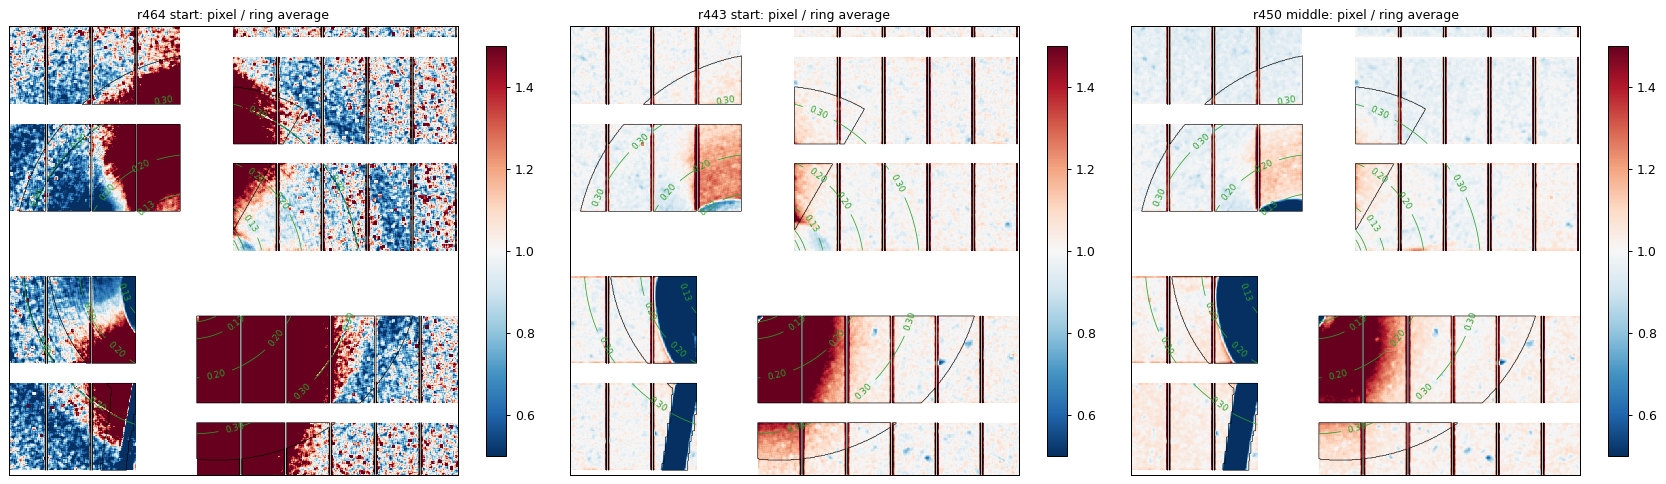

In [6]:
b464s = block(464, "start", v0_run=464, ferritin_mg_per_ml_initial=0)
b443s = block(443, "start", v0_run=443)
b450m = block(450, "middle", v0_run=443)

fig, axs = plt.subplots(1, 3, figsize=(19, 6))
for ax, b in zip(axs, (b464s, b443s, b450m)):
    resid = smoothed_mean(b, 5) / ring_average(b["mean"])
    show(ax, resid, f"{b['name']}: pixel / ring average", mpl.colors.Normalize(0.5, 1.5), "RdBu_r", half=330)
plt.tight_layout()
plt.show()

The same data as an I(q, χ) map, **without** the static mask, each q row divided by its median over the unmasked
pixels. The streak is the red band at χ ≈ −90° to −30° and its weaker partner at χ ≈ +100° to +130°. The rightmost panel
shows which (q, χ) cells the static mask removes (black).

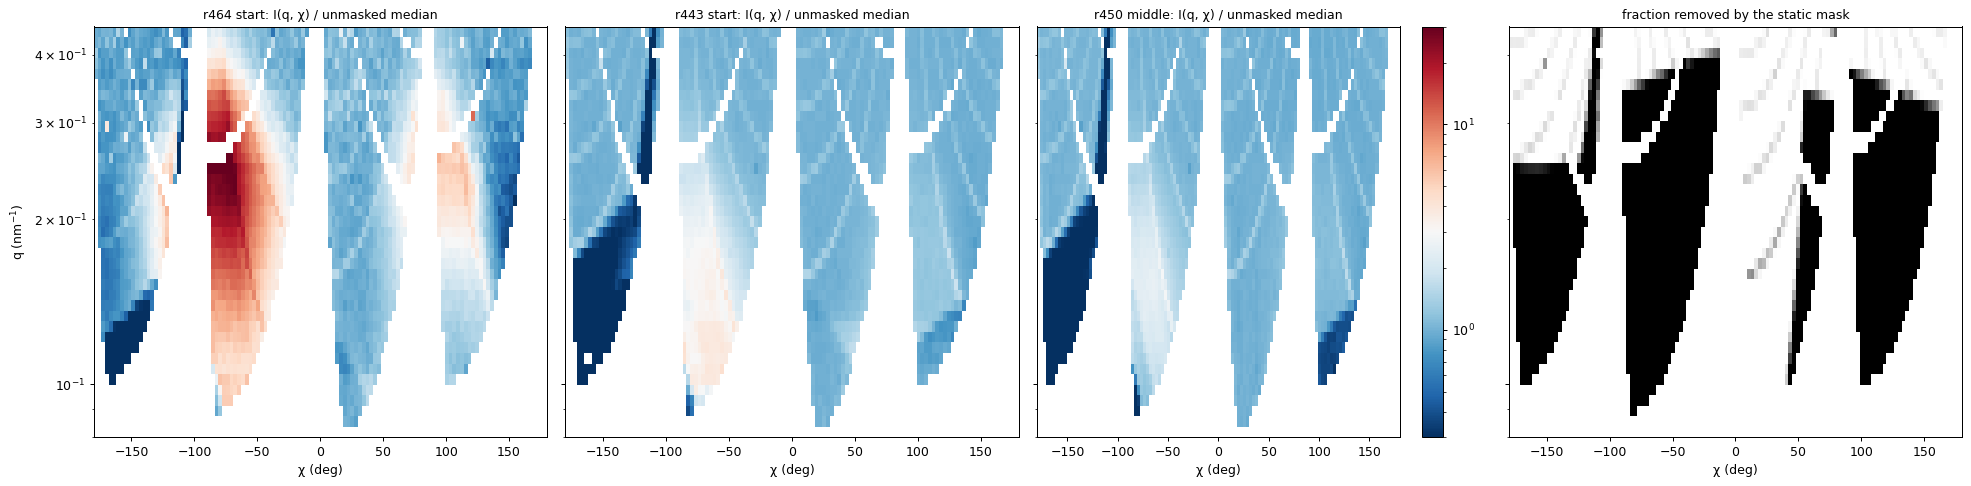

In [7]:
qe2, ce2 = np.geomspace(0.08, 0.45, 40), np.linspace(-180, 180, 121)


def cake(img, sel):
    ok = sel & np.isfinite(img)
    num, _, _ = np.histogram2d(Q[ok], CHI[ok], [qe2, ce2], weights=img[ok])
    cnt, _, _ = np.histogram2d(Q[ok], CHI[ok], [qe2, ce2])
    with np.errstate(invalid="ignore", divide="ignore"):
        return num / cnt, cnt


fig, axs = plt.subplots(1, 4, figsize=(22, 5.5), sharey=True)
for ax, b in zip(axs, (b464s, b443s, b450m)):
    full, _ = cake(b["mean"], np.ones_like(WEDGE))
    good, gcnt = cake(b["mean"], WEDGE)
    with np.errstate(invalid="ignore"):
        ref = np.nanmedian(np.where(gcnt > 3, good, np.nan), axis=1)
    im = ax.pcolormesh(ce2, qe2, full / ref[:, None], norm=LogNorm(0.3, 30), cmap="RdBu_r")
    ax.set_yscale("log")
    ax.set_title(f"{b['name']}: I(q, χ) / unmasked median", fontsize=10)
    ax.set_xlabel("χ (deg)")
fig.colorbar(im, ax=axs[2])
frac, _ = cake(STATIC_BAD.astype(float), np.ones_like(WEDGE))
axs[3].pcolormesh(ce2, qe2, frac, cmap="Greys", vmin=0, vmax=1)
axs[3].set_title("fraction removed by the static mask", fontsize=10)
axs[3].set_xlabel("χ (deg)")
axs[0].set_ylabel("q (nm$^{-1}$)")
plt.tight_layout()
plt.show()

## 3. The streak scales with the incoming beam, not with the droplet

If the streak were scattering from the droplet, its strength would follow the droplet's scattering volume, i.e.
flux × path (tT). If it were stray light that passes through the droplet, it would follow flux × T. If it never meets
the droplet, it follows the flux alone. The table compares the streak excess E (lobe region χ −80° to −40°,
q 0.15–0.25 nm⁻¹, above the ring average) for four blocks whose droplet transmission T differs four-fold.
**E/F is the only column that stays constant.**

In [8]:
b465s = block(465, "start", v0_run=464, ferritin_mg_per_ml_initial=0)
rows = []
for b in (b443s, b450m, b464s, b465s):
    e = streak_excess(b, -80, -40)  # x1e6, per unit flux
    rows.append({"block": b["name"], "droplet transmission T": b["T"], "thickness t (mm)": 2 * b["a_x"],
                 "E / F": e, "E / (F·T)": e / b["T"], "E / (F·t·T)": e / b["path"]})
tab = pd.DataFrame(rows).set_index("block")
spread = (tab.max() / tab.min()).rename("max / min")
pd.concat([tab, spread.to_frame().T])

,droplet transmission T,thickness t (mm),E / F,E / (F·T),E / (F·t·T)
r443 start,0.164,1.927,178.910,1088.661,564.971
r450 middle,0.105,1.073,204.576,1948.205,1815.223
r464 start,0.328,1.470,162.241,494.916,336.776
r465 start,0.425,1.063,157.180,369.856,348.040
max / min,4.047,1.813,1.302,5.267,5.390


**Reading:** E/F varies by about ±13 % (max/min 1.30) while E/(F·tT), the normalisation that sample scattering needs,
varies 5.4×. The streak is
therefore produced upstream or around the droplet, not in it. Normalising a frame by flux × path (as every sample I(q)
must be) amplifies the streak by 1/(tT), which differs between droplets.

## 4. The droplet casts a shadow on the stray light near the beam

### 4a. Mesh scan, run 318 (11 May)

During run 318 the sample hexapod (`MID_EXP_SAM/HEXAPOD/SSHEX`) moved the droplet across the beam: X stepped through
1 mm, and Z alternated between two heights. The water signal at q = 0.85–0.95 nm⁻¹ shows whether the beam hit the droplet.
Four groups of trains are compared (at most 60 trains each, spread over the scan). The groups' trains are scattered over
the scan, so their per-pixel sums come from `analysis.cache.detector_sums` rather than the pass's 10-train windows (only
one window lies entirely beside the droplet on the −X side):

* **beam only:** the beam passes below/above the droplet (lower Z), no water signal;
* **droplet beside (+X)** and **(−X):** upper Z, but X beyond the droplet's edge on either side, no water signal;
* **through droplet:** upper Z, central X.

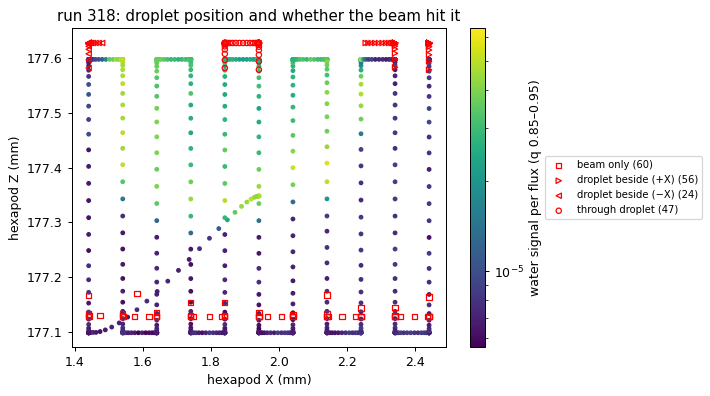

In [9]:
MESH_RUN, MESH_PULSES = 318, 350
rd318 = run_data(MESH_RUN, n_pulses=MESH_PULSES)
raw318 = ed.open_run(10400, MESH_RUN, data="raw")
pos = xr.Dataset({
    "x": raw318["MID_EXP_SAM/HEXAPOD/SSHEX", "X.actualPosition.value"].xarray(),
    "z": raw318["MID_EXP_SAM/HEXAPOD/SSHEX", "Z.actualPosition.value"].xarray(),
})
complete = (rd318.n_pulses_with_frames == MESH_PULSES) & np.isfinite(rd318.flux)
water = (rd318.intensity.sel(q=slice(0.85, 0.95)).mean("q") / rd318.flux).where(complete)
mesh = xr.merge([pos, water.rename("water")], join="inner").dropna("trainId")

z_low = mesh.z < float(mesh.z.min()) + 0.05
z_high = mesh.z > float(mesh.z.max()) - 0.05
hit = mesh.water > 2 * float(mesh.water.where(z_low).median())
x_hit = mesh.x.where(z_high & hit)
x_lo, x_hi = float(x_hit.min()), float(x_hit.max())
groups = {
    "beam only": z_low & ~hit,
    "droplet beside (+X)": z_high & ~hit & (mesh.x > x_hi),
    "droplet beside (−X)": z_high & ~hit & (mesh.x < x_lo),
    "through droplet": z_high & hit & (abs(mesh.x - (x_lo + x_hi) / 2) < (x_hi - x_lo) / 6),
}


def pick(sel, n=60):
    tids = mesh.trainId.values[sel.values]
    return tids[np.linspace(0, tids.size - 1, min(n, tids.size)).round().astype(int)]


labels = {"beam only": "beamonly", "droplet beside (+X)": "besideplus", "droplet beside (−X)": "besideminus",
          "through droplet": "through"}
mesh_blocks = {
    name: block_from_sums(MESH_RUN, cache.detector_sums(MESH_RUN, pick(sel), label=labels[name]), rd318, labels[name])
    for name, sel in groups.items()
}

fig, ax = plt.subplots(figsize=(8, 4.5))
sc = ax.scatter(mesh.x, mesh.z, c=mesh.water, norm=LogNorm(), s=8, cmap="viridis")
for (name, b), mk in zip(mesh_blocks.items(), ["s", ">", "<", "o"]):
    sel = mesh.sel(trainId=b["trains"])
    ax.scatter(sel.x, sel.z + 0.03, marker=mk, s=18, facecolors="none", edgecolors="r", label=f"{name} ({len(b['trains'])})")
plt.colorbar(sc, label="water signal per flux (q 0.85–0.95)")
ax.set_xlabel("hexapod X (mm)")
ax.set_ylabel("hexapod Z (mm)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.25, 0.5))
ax.set_title(f"run {MESH_RUN}: droplet position and whether the beam hit it")
plt.tight_layout()
plt.show()

Per-flux images of each group divided by the beam-only image, then the azimuthal average each group would give.

* **Droplet beside the beam, +X side:** a dark spot appears exactly on the lowest-q corner of the unmasked wedge. Stray
  light that would have reached those pixels now passes through the droplet and is absorbed. The wedge average drops
  below q ≈ 0.12 nm⁻¹ (to ×0.46 at 0.09 nm⁻¹) and is unchanged above.
* **Droplet beside the beam, −X side:** the lowest q is barely affected (×0.92), so the shadow falls elsewhere; but above
  q ≈ 0.2 nm⁻¹ the wedge gains up to ~2×, possibly from the beam grazing the droplet's edge.
* **Beam through the droplet:** its own scattering dominates everywhere.
* **Beam only:** note that even without a droplet in the beam, the wedge receives a steep stray-light background below
  q ≈ 0.2 nm⁻¹. Every sample measurement sits on top of it.

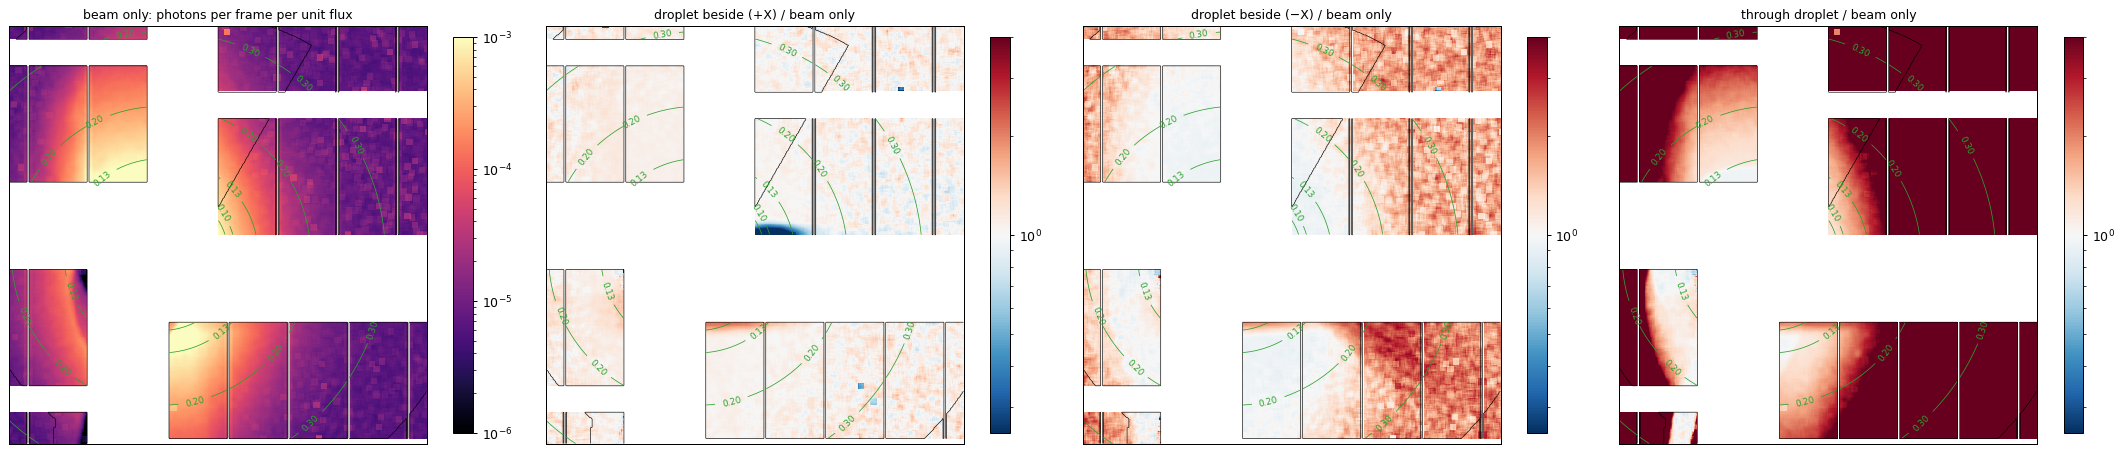

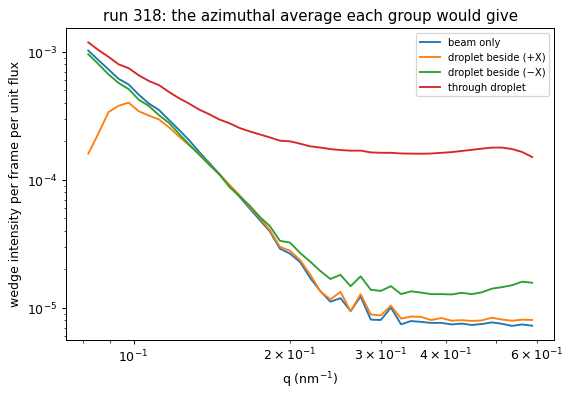

,q = 0.089,q = 0.098,q = 0.117,q = 0.128,q = 0.160,q = 0.200
relative to beam only,,,,,,
droplet beside (+X),0.464,0.721,0.877,0.916,1.029,1.053
droplet beside (−X),0.916,0.921,0.948,0.926,1.008,1.219
through droplet,1.255,1.339,1.654,1.932,3.445,7.531


In [10]:
ref = smoothed_mean(mesh_blocks["beam only"]) / mesh_blocks["beam only"]["flux"]
fig, axs = plt.subplots(1, 4, figsize=(24, 5.8))
show(axs[0], ref, "beam only: photons per frame per unit flux", LogNorm(1e-6, 1e-3), "magma")
for ax, name in zip(axs[1:], ["droplet beside (+X)", "droplet beside (−X)", "through droplet"]):
    b = mesh_blocks[name]
    show(ax, smoothed_mean(b) / b["flux"] / ref, f"{name} / beam only", LogNorm(0.25, 4), "RdBu_r")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, b in mesh_blocks.items():
    ax.loglog(QC, profile(b["mean"], WEDGE) / b["flux"], label=name)
ax.set_xlabel("q (nm$^{-1}$)")
ax.set_ylabel("wedge intensity per frame per unit flux")
ax.set_title(f"run {MESH_RUN}: the azimuthal average each group would give")
ax.legend(fontsize=8)
plt.show()
rows = {name: profile(b["mean"], WEDGE) / b["flux"] / (profile(mesh_blocks["beam only"]["mean"], WEDGE)
                                                      / mesh_blocks["beam only"]["flux"])
        for name, b in mesh_blocks.items() if name != "beam only"}
pick_q = [np.argmin(abs(QC - x)) for x in (0.088, 0.10, 0.115, 0.13, 0.16, 0.2)]
pd.DataFrame({name: r[pick_q] for name, r in rows.items()}, index=[f"q = {QC[i]:.3f}" for i in pick_q]).T.rename_axis(
    "relative to beam only")

### 4b. The shadow grows with the droplet

Two blocks of the same buffer droplet at different sizes: `r464 start` (horizontal semi-axis ≈ 0.73 mm) and `r465 start`
(≈ 0.53 mm, after evaporation). Divided per unit flux, the two agree everywhere except in the innermost corner of the wedge
(q below ≈ 0.11 nm⁻¹), where the larger droplet shadows more. This size dependence is why a buffer droplet of another size
cannot remove the effect from a sample droplet.

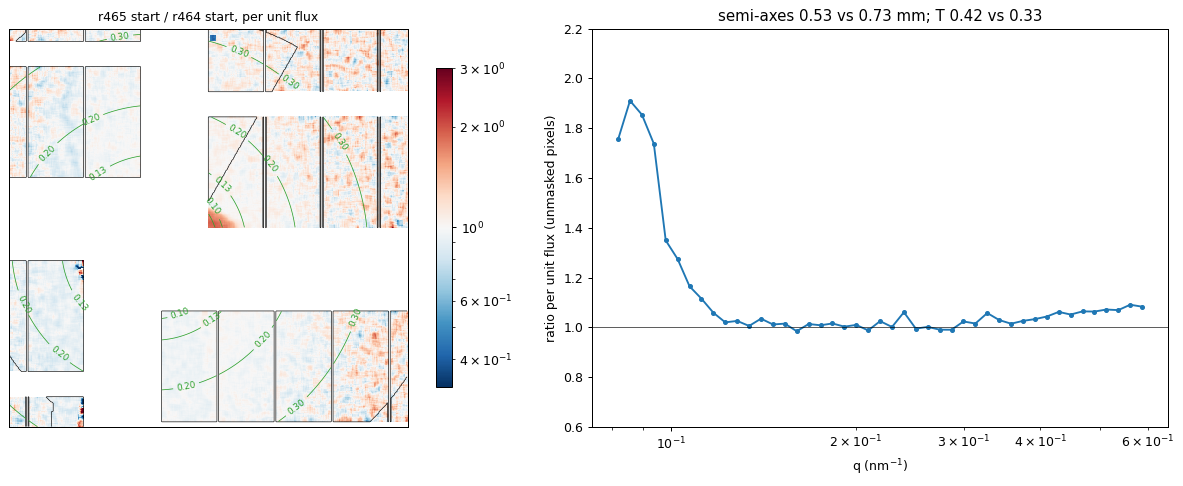

In [11]:
ratio_img = (smoothed_mean(b465s) / b465s["flux"]) / (smoothed_mean(b464s) / b464s["flux"])
fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))
show(axs[0], ratio_img, "r465 start / r464 start, per unit flux", LogNorm(0.33, 3), "RdBu_r")
r_wedge = (profile(b465s["mean"], WEDGE) / b465s["flux"]) / (profile(b464s["mean"], WEDGE) / b464s["flux"])
axs[1].semilogx(QC, r_wedge, "o-", ms=3)
axs[1].axhline(1, color="k", lw=0.5)
axs[1].set_xlabel("q (nm$^{-1}$)")
axs[1].set_ylabel("ratio per unit flux (unmasked pixels)")
axs[1].set_ylim(0.6, 2.2)
axs[1].set_title(f"semi-axes {b465s['a_x']:.2f} vs {b464s['a_x']:.2f} mm; T {b465s['T']:.2f} vs {b464s['T']:.2f}")
plt.tight_layout()
plt.show()

## 5. What this does to the buffer-subtracted I(q)

Subtraction as used in the analysis: each frame is divided by flux × path, and the buffer, taken at the same normalised
time t/t* of its own evaporation (t* is where the droplet's D² law ends), is subtracted with weight (1 − φ), where φ is the
ferritin volume fraction. The curves below come from the same block split into three azimuthal sectors of the wedge.
For a fresh (large) droplet they disagree below ≈ 0.14 nm⁻¹; above that they coincide.

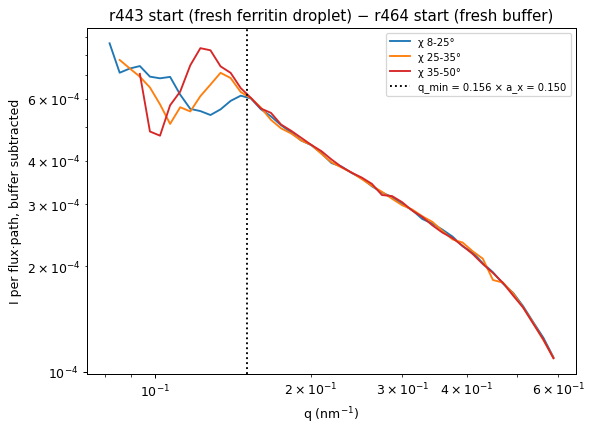

In [12]:
def subtracted(sample, buffer):
    "Sample minus (1 - phi) x buffer, both per flux*path, as module-shaped images."
    return sample["mean"] / (sample["flux"] * sample["path"]) - (1 - sample["phi"]) * buffer["mean"] / (
        buffer["flux"] * buffer["path"])


d = subtracted(b443s, b464s)
fig, ax = plt.subplots(figsize=(7, 5))
for (name, sel), c in zip(SECTORS.items(), ["C0", "C1", "C3"]):
    ax.loglog(QC, profile(d, sel), color=c, label=name)
ax.axvline(0.156 * b443s["a_x"], color="k", ls=":", label=f"q_min = 0.156 × a_x = {0.156 * b443s['a_x']:.3f}")
ax.set_xlabel("q (nm$^{-1}$)")
ax.set_ylabel("I per flux·path, buffer subtracted")
ax.set_title("r443 start (fresh ferritin droplet) − r464 start (fresh buffer)")
ax.legend(fontsize=8)
plt.show()

### The lowest trustworthy q follows the droplet size

For blocks along the whole evaporation of the ferritin droplet (runs 443–452) we take the lowest q above which the three
sectors agree. "Agree" means: no two neighbouring q bins where the largest sector deviation exceeds 4× that block's own
typical sector scatter at 0.2–0.5 nm⁻¹ (≈ 1 %). Each sample block is paired with the buffer block nearest in t/t*. The dashed
line is the rule used in the analysis, q_min = 0.156 nm⁻¹ per mm of horizontal semi-axis a_x.

**Reading:** while the droplet evaporates (a_x from 0.96 to 0.63 mm, t/t* < 1) the lowest q where the sectors agree follows
the rule within ±0.01 nm⁻¹. On the plateau after t* (a_x ≈ 0.53–0.57 mm) it stays near 0.10 nm⁻¹ instead of falling to
0.08 nm⁻¹, and the last block (r452 end, t/t* ≈ 3) disagrees up to 0.15 nm⁻¹. The analysis therefore never goes below
0.11 nm⁻¹; why the late blocks disagree (the stray light, or the sample itself becoming anisotropic as it crystallises)
is open.

sample t* = 1010 s (fit); buffer t* = 718 s (end of its clean data: the buffer droplet became unstable before its D² law ended)


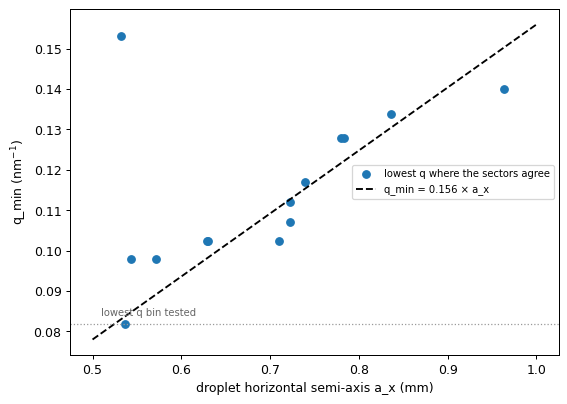

,t/t*,V/V0,a_x (mm),buffer,sector scatter,q_min found,rule 0.156·a_x
block,,,,,,,
r443 start,9.699e-04,0.994,0.963,r464 start,0.009,0.140,0.150
r443 middle,1.486e-01,0.808,0.837,r464 middle,0.008,0.134,0.131
r443 end,2.960e-01,0.661,0.783,r464 middle,0.009,0.128,0.122
r444 start,3.048e-01,0.652,0.779,r464 middle,0.009,0.128,0.122
r444 middle,4.520e-01,0.521,0.739,r465 start,0.008,0.117,0.115
r444 end,5.995e-01,0.404,0.723,r465 middle,0.008,0.112,0.113
r445 start,6.082e-01,0.399,0.722,r465 middle,0.009,0.107,0.113
r445 middle,7.543e-01,0.324,0.710,r465 end,0.008,0.102,0.111
r445 end,9.022e-01,0.243,0.630,r466 start,0.009,0.102,0.098


In [13]:
SAMPLE_RUNS, BUFFER_RUNS = [443, 444, 445, 446, 448, 449, 450, 451, 452], [464, 465, 466]
tl_s = cache.droplet_timeline(SAMPLE_RUNS, db)
tl_b = cache.droplet_timeline(BUFFER_RUNS, db, stop_at_min_volume=True, t_star="end")
print(f"sample t* = {tl_s.attrs['t_star_s']:.0f} s (fit); buffer t* = {tl_b.attrs['t_star_s']:.0f} s "
      f"(end of its clean data: the buffer droplet became unstable before its D² law ended)")


def tau(b, tl):
    return float((tl.elapsed_s.sel(trainId=b["trains"]) / tl.attrs["t_star_s"]).mean())


sample_blocks = [block(r, w, v0_run=443) for r, w in [
    (443, "start"), (443, "middle"), (443, "end"), (444, "start"), (444, "middle"), (444, "end"), (445, "start"),
    (445, "middle"), (445, "end"), (446, "start"), (446, "middle"), (448, "middle"), (450, "middle"), (452, "end")]]
buffer_blocks = [b464s, b465s] + [block(r, w, v0_run=464, ferritin_mg_per_ml_initial=0) for r, w in [
    (464, "middle"), (464, "end"), (465, "middle"), (465, "end"), (466, "start"), (466, "middle")]]
buffer_tau = np.array([tau(b, tl_b) for b in buffer_blocks])


def q_min_from_sectors(d):
    y = np.array([profile(d, sel) for sel in SECTORS.values()])
    mean = np.nanmean(y, 0)
    rel = np.abs(y - mean) / np.abs(mean)
    floor = np.sqrt(np.nanmean(rel[:, (QC >= 0.2) & (QC <= 0.5)] ** 2))
    bad = (np.nanmax(rel, 0) > 4 * floor) & (QC < 0.25)
    pair = bad[:-1] & bad[1:]
    return (QC[1:][pair].max() if pair.any() else QC[0]), floor


rows = []
for b in sample_blocks:
    t = tau(b, tl_s)
    buf = buffer_blocks[int(np.argmin(abs(buffer_tau - min(t, buffer_tau.max()))))]
    qmin, floor = q_min_from_sectors(subtracted(b, buf))
    rows.append({"block": b["name"], "t/t*": t, "V/V0": b["vv0"], "a_x (mm)": b["a_x"], "buffer": buf["name"],
                 "sector scatter": floor, "q_min found": qmin, "rule 0.156·a_x": 0.156 * b["a_x"]})
qmin_tab = pd.DataFrame(rows).set_index("block")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(qmin_tab["a_x (mm)"], qmin_tab["q_min found"], "o", label="lowest q where the sectors agree")
xx = np.linspace(0.5, 1.0, 10)
ax.plot(xx, 0.156 * xx, "k--", label="q_min = 0.156 × a_x")
ax.axhline(QC[0], color="0.6", ls=":", lw=1)
ax.text(0.51, QC[0] + 0.002, "lowest q bin tested", fontsize=8, color="0.4")
ax.set_xlabel("droplet horizontal semi-axis a_x (mm)")
ax.set_ylabel("q_min (nm$^{-1}$)")
ax.legend(fontsize=8)
plt.show()
qmin_tab

## 6. The stray light changes between days and attenuator settings

The streak excess per unit flux in the main lobe (χ −80° to −40°) and its opposite (χ +100° to +130°), for fresh ferritin
droplets on 11 May (run 394, no PEG), 12 May at attenuator 1.0 (run 443) and 12 May at attenuator 0.506 (run 467). On
11 May the opposite lobe is the strong one; the pattern switched between run 433 (11 May 23:31) and run 443 (12 May
00:32). At attenuator 0.506 the main lobe reads ~1.3–1.4× higher per unit of logged flux.

In [14]:
b394s = block(394, "start", v0_run=394, peg_percent_wv_initial=0.0)
b467s = block(467, "start", v0_run=467)
rows = []
for b in (b394s, b443s, b467s):
    rows.append({"block": b["name"], "attenuator": b["t_att"], "lobe χ −80…−40 (E/F ×1e6)": streak_excess(b, -80, -40),
                 "opposite χ +100…+130 (E/F ×1e6)": streak_excess(b, 100, 130)})
pd.DataFrame(rows).set_index("block")

,attenuator,lobe χ −80…−40 (E/F ×1e6),opposite χ +100…+130 (E/F ×1e6)
block,,,
r394 start,1.000,39.609,134.397
r443 start,1.000,178.910,29.840
r467 start,0.506,244.547,27.191


The droplets' own scattering tells the same story about the attenuator. At the very start of a droplet (V/V₀ ≈ 1) every
ferritin droplet has the same composition, so its scattering per flux × path should be the same. The three droplets at
attenuator 0.506 agree with each other within a few per cent but sit ~1.3× above the ones at 1.0 from the same night
(runs 443 and 453). Runs 423 and 433 (11 May, the other stray-light period) are shown for completeness; they scatter
more widely.

In [15]:
rows = []
for run in (423, 433, 443, 453, 467, 477, 487):
    rd = run_data(run, v0_run=run)
    usable = (rd.n_pulses_with_frames == 155) & np.isfinite(rd.scale)
    s = rd.sel(trainId=rd.trainId.values[usable.values][:20])  # the first 20 complete trains
    y = (s.intensity * s.scale).mean("trainId")
    rows.append({"run": run, "attenuator": float(s.total_transmission.mean()), "V/V0": float(s.v_over_v0.mean()),
                 "I/(F·tT) at q 0.30–0.35 (×1e5)": float(y.sel(q=slice(0.30, 0.35)).mean()) * 1e5,
                 "I/(F·tT) at q 0.85–0.95 (×1e5)": float(y.sel(q=slice(0.85, 0.95)).mean()) * 1e5})
pd.DataFrame(rows).set_index("run")

,attenuator,V/V0,I/(F·tT) at q 0.30–0.35 (×1e5),I/(F·tT) at q 0.85–0.95 (×1e5)
run,,,,
423,1.000,0.999,17.056,1.205
433,1.000,0.997,33.405,2.361
443,1.000,0.994,28.172,1.960
453,1.000,1.001,24.660,1.725
467,0.506,0.996,33.707,2.388
477,0.506,0.999,37.194,2.730
487,0.506,1.001,35.673,2.531


## 7. Where this leaves the analysis, and what we would like to ask

**What we do now.** I(q) is used only above the droplet-size-dependent q_min (0.156 nm⁻¹ per mm of semi-axis, never below
0.11 nm⁻¹), with the caveat of section 5 for the late, non-evaporating part of a droplet. The buffer is subtracted per flux × path at the same t/t*. Runs at attenuator 0.506
are scaled by 1/1.3 to the attenuator-1.0 scale. Two alternatives were tested and rejected: subtracting the buffer per unit
flux (it removes the streak in the masked lobes above q ≈ 0.25 nm⁻¹ but over-subtracts the shadowed region and makes the
wedge less consistent); and filtering trains or pulses (the effects are stable train to train and pulse to pulse, with no
outlier frames).

**What we cannot do without help.** Recover the region below q_min, especially for fresh droplets, where it would carry
the Guinier region of ferritin and the first signs of aggregation.

**Questions for the MID team**

1. **Source of the streak.** Which component produces a stray-light streak through the beam at χ ≈ −60°/+120° (pyFAI
   azimuth in our geometry)? From the size dependence of the shadow, the source appears to sit roughly 0.3 m upstream of the
   droplet (a rough geometric estimate). Candidates we can think of: slit or pinhole edges, a window, the air path. Is
   there a record of the slit, aperture and beamstop settings around the levitator?
2. **What changed between runs 433 and 443** (11 May 23:31 → 12 May 00:32)? The streak pattern switched, consistent with a
   change in slits, apertures or beam steering.
3. **Beam-only measurements.** Is there any beam-on, no-droplet data in the 12 May configuration (attenuator 1.0 and
   0.506, 155 pulses)? Run 55 (10 May) is ~500× brighter per unit flux and clearly a different setup; the mesh scans of 11 May
   (e.g. run 318) are close but not identical.
4. **Attenuator 0.506.** Is the logged transmission of 0.506 correct at 9.04 keV? Both the streak and the droplet scattering
   suggest the effective transmission is ~1.3–1.4× higher (≈ 0.65–0.7), relative to the setting logged as 1.0.
5. **Beam centre.** We use (607.46, 672.08) px in the `to_distortion_array` frame of `geom_latest.geom`. A different
   construction places it ~20 px away in y, which would matter most for exactly this low-q wedge. What is the best
   reference for the beam centre on 11–12 May?
6. **Photon energy.** The analysis uses 9.04 keV; the XGM reports 9.000 keV. Which is correct?
7. **Mask.** The static mask (`mask_2026-09-08_AGIPD_SAXS.npy`) removes the streak core and leaves only one wedge below
   0.2 nm⁻¹. Is there a better way at MID to recover the low-q region for samples that sit in stray light (for example a
   different beamstop or guard aperture configuration we should have used)?

### Appendix: methods and reproducibility

* Detector data: corrected (proc) AGIPD frames, photon counts; a pixel is used in a frame only if its correction mask is 0.
  The static mask (bad pixels, ASIC seams and the masked low-q lobe) is applied on top, as in the integration pass.
* Flux: XGM `SA2_XTD1_XGM` pulse energy averaged per train over the same pulses as the detector (per-pulse XGM values
  are unreliable at 2.26 MHz), times the attenuator transmission logged by DAMNIT.
* Droplet thickness and transmission: horizontal semi-axis from the droplet camera fit (13.9 µm/px), and µ from the
  composition (xraydb at 9.04 keV); see `analysis.utils.droplet_scaling`.
* All stored data (the pass's per-pixel window sums, `analysis.saxs.pixel_sums`, and `analysis.cache`) are raw sums
  or pulse averages with their metadata. Subtraction and normalisation
  happen only in this notebook.